# ⚡ LangGraph: Parallelization Workflow (Fan-Out / Fan-In)

### 📌 Overview
This notebook implements the Sectioning variation of the Parallelization workflow pattern.

When a workflow has independent subtasks that do not rely on one another, LangGraph executes them concurrently (*Fan-Out*), waits for all branches to finish, and fans into an aggregator node (*Fan-In*):
1. **Parallel Processing (Fan-Out):** Three specialized nodes calculate yearly compensation, bonus calculations, and project evaluations simultaneously.
2. **Aggregator Synthesis (Fan-In):** An LLM node powered by OpenRouter (`qwen/qwen3.8-27b:free`) ingests the combined metrics and drafts a comprehensive executive performance report.

---

### 🗺️ Graph Topology

```text
                         ┌─────────────────────────────┐
                    ┌──► │   calculate_yearly_salary   │ ──┐
                    │    └─────────────────────────────┘   │
                    │    ┌─────────────────────────────┐   │
         ┌─────────┐├──► │       calculate_bonus       │ ──┼──► ┌────────────────────┐       ┌───────┐
         │  START  ││    └─────────────────────────────┘   │    │  generate_summary  │ ────► │  END  │
         └─────────┘│    ┌─────────────────────────────┐   │    └────────────────────┘       └───────┘
                    └──► │     project_evaluation      │ ──┘
                         └─────────────────────────────┘
```

*Execution Flow:*
* `START` fans out concurrently to `calculate_yearly_salary`, `calculate_bonus`, and `project_evaluation`.
* All three parallel nodes join at `generate_summary` (LLM Aggregator).
* `generate_summary` ➔ `END`.

In [1]:
import os
from typing import NotRequired, TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

# Load variables from .env
load_dotenv()

# Verify OpenRouter key
if not os.getenv("OPENROUTER_API_KEY"):
    raise ValueError(
        "OPENROUTER_API_KEY is missing. Please add it to your .env file: "
        "OPENROUTER_API_KEY=sk-or-v1-..."
    )

### 2. Initialize LLM via OpenRouter
We use `ChatOpenAI` configured with OpenRouter's endpoint and the free `qwen/qwen3.8-27b:free` model to act as our synthesis aggregator.

In [8]:
# OpenRouter configuration with qwen/qwen3.8-27b:free
model = ChatOpenAI(
    model="qwen/qwen3.8-27b:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7,
)

### 3. Define Graph State Schema
The state tracks both input parameters and the outputs computed by parallel branches:
* **Inputs:** `employee_name`, `monthly_salary`, `working_days`, `completed_projects`.
* **Parallel Outputs:** `yearly_salary`, `bonus_amount`, `project_status` (marked `NotRequired`).
* **Final Aggregated Output:** `summary` (marked `NotRequired`).

In [3]:
class EmployeeState(TypedDict):
    # Required inputs provided at invocation
    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    # Derived metrics produced by parallel nodes
    yearly_salary: NotRequired[int]
    bonus_amount: NotRequired[int]
    project_status: NotRequired[str]

    # Final summary generated by LLM aggregator
    summary: NotRequired[str]

### 4. Define Parallel Worker Nodes (Deterministic)
Each node executes an independent calculation and returns **only its specific delta**. 
Because each node updates an independent key, LangGraph merges them concurrently without state contention.

In [4]:
def calculate_yearly_salary(state: EmployeeState) -> dict:
    """Worker 1: Computes the base yearly salary."""
    yearly_salary = state["monthly_salary"] * 12
    return {"yearly_salary": yearly_salary}


def calculate_bonus(state: EmployeeState) -> dict:
    """Worker 2: Calculates annual bonus based on company performance multiplier."""
    bonus_amount = state["monthly_salary"] * 2
    return {"bonus_amount": bonus_amount}


def project_evaluation(state: EmployeeState) -> dict:
    """Worker 3: Assesses performance rating based on project delivery volume."""
    status = "Excellent" if state["completed_projects"] >= 5 else "Average"
    return {"project_status": status}

### 5. Define the Aggregator Node (LLM Synthesis)
This node acts as the **Fan-In synchronization barrier**. It runs only after all three parallel nodes complete, synthesizing their combined metrics into a polished executive report.

In [5]:
def generate_summary(state: EmployeeState) -> dict:
    """Aggregator Node: Consumes parallel metrics and generates an executive summary using the LLM."""
    name = state["employee_name"]
    yearly_salary = state["yearly_salary"]
    bonus = state["bonus_amount"]
    status = state["project_status"]
    projects = state["completed_projects"]
    total_comp = yearly_salary + bonus

    messages = [
        (
            "system",
            "You are an executive HR and workforce analytics specialist. "
            "Generate a professional, structured performance and compensation review.",
        ),
        (
            "human",
            f"Please generate a comprehensive employee assessment report based on these verified metrics:\n"
            f"- Employee Name: {name}\n"
            f"- Annual Base Salary: ${yearly_salary:,}\n"
            f"- Performance Bonus: ${bonus:,}\n"
            f"- Total Compensation: ${total_comp:,}\n"
            f"- Projects Completed: {projects}\n"
            f"- Performance Rating: {status}\n\n"
            f"Provide an executive overview, compensation analysis, and key recommendations.",
        ),
    ]

    response = model.invoke(messages)
    return {"summary": str(response.content)}

### 6. Build and Compile the Parallel Graph
* **Fan-Out:** We wire three edges from `START` to each worker node.
* **Fan-In:** We wire three edges from the worker nodes to `generate_summary`. LangGraph automatically waits for all incoming branches to finish before executing the aggregator.

In [6]:
# 1. Initialize builder
builder = StateGraph(EmployeeState)

# 2. Register all nodes
builder.add_node("calculate_yearly_salary", calculate_yearly_salary)
builder.add_node("calculate_bonus", calculate_bonus)
builder.add_node("project_evaluation", project_evaluation)
builder.add_node("generate_summary", generate_summary)

# 3. Define Fan-Out (START -> 3 Parallel Workers)
builder.add_edge(START, "calculate_yearly_salary")
builder.add_edge(START, "calculate_bonus")
builder.add_edge(START, "project_evaluation")

# 4. Define Fan-In (3 Workers -> Aggregator)
builder.add_edge("calculate_yearly_salary", "generate_summary")
builder.add_edge("calculate_bonus", "generate_summary")
builder.add_edge("project_evaluation", "generate_summary")

# 5. Final edge to END
builder.add_edge("generate_summary", END)

# 6. Compile workflow
workflow = builder.compile()

### 7. Execute the Workflow
We execute the workflow with sample employee records and print the final aggregated state.

In [9]:
sample_input = {
    "employee_name": "Elena Rostova",
    "monthly_salary": 7500,
    "working_days": 220,
    "completed_projects": 7,
}

print("--- Running Parallel Workflow (.invoke) ---\n")
final_state = workflow.invoke(sample_input)

print("=" * 60)
print("PARALLEL METRICS SUMMARY:")
print("=" * 60)
print(f"Base Yearly Salary: ${final_state['yearly_salary']:,}")
print(f"Bonus Awarded:      ${final_state['bonus_amount']:,}")
print(f"Performance Tier:  {final_state['project_status']}")

print("\n" + "=" * 60)
print("EXECUTIVE AI SUMMARY REPORT:")
print("=" * 60)
print(final_state["summary"])

--- Running Parallel Workflow (.invoke) ---

PARALLEL METRICS SUMMARY:
Base Yearly Salary: $90,000
Bonus Awarded:      $15,000
Performance Tier:  Excellent

EXECUTIVE AI SUMMARY REPORT:
# Employee Assessment Report: Elena Rostova

## 1. Executive Overview

Elena Rostova is a high-performing employee with a strong delivery record and a performance rating of **Excellent**. Over the review period, she completed **7 projects**, demonstrating consistent output, reliability, and the ability to contribute meaningfully to organizational goals.

Her total compensation of **$105,000**, comprising a **$90,000 annual base salary** and a **$15,000 performance bonus**, reflects a compensation structure that rewards performance while maintaining a stable base pay foundation. The bonus component represents approximately **16.7% of base salary**, indicating a meaningful performance-based incentive aligned with her Excellent rating.

Overall, Elena Rostova appears to be a valuable contributor with stron

### 8. Visualize Graph Topology
Displays the compiled execution graph with an automatic offline ASCII fallback.

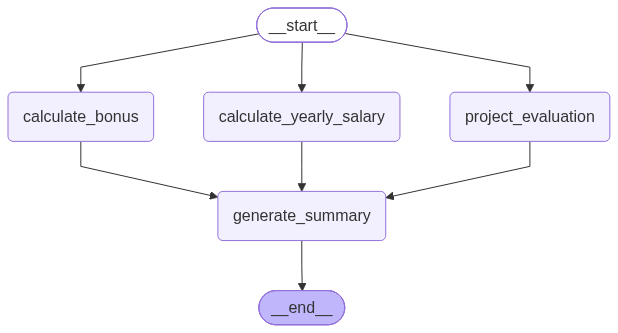

In [10]:
try:
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid image renderer unavailable. Displaying ASCII graph instead:\n")
    print(workflow.get_graph().draw_ascii())